Clustering (full dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt


In [ ]:
BASE = os.path.abspath(os.path.join(os.getcwd(), "../../"))

actsummary_dfs = {}
years = [y for y in range(2010, 2025) if y != 2020]
for year in years:
    actsummary_dfs[year] = pd.read_csv(os.path.join(BASE, f'ATUS Data/atussum_{year}.dat'))
    actsummary_dfs[year].columns = actsummary_dfs[year].columns.str.upper()
    actsummary_dfs[year]['YEAR'] = year

final_df = pd.concat(actsummary_dfs.values(), ignore_index=True)
drop = ['TUCASEID', 'TUFINLWGT', 'TRYHHCHILD', 'TEAGE', 'TESEX', 'PEEDUCA', 'PTDTRACE', 'PEHSPNON', 'GTMETSTA', 'TELFS', 'TEMJOT', 'TRDPFTPT', 'TESCHENR', 'TESCHLVL', 'TRSPPRES', 'TESPEMPNOT', 'TRERNWA', 'TRCHILDNUM', 'TRSPFTPT', 'TEHRUSLT', 'TUDIARYDAY', 'TRHOLIDAY', 'TRTEC', 'TRTHH','T500101', 'T500103', 'T500105', 'T500106', 'T500107', 'T509999']
cluster_df = final_df.drop(columns=drop)
cluster_df = cluster_df.dropna(axis=1)
print(cluster_df.columns.tolist())

['T010101', 'T010102', 'T010201', 'T010299', 'T010301', 'T010399', 'T010401', 'T020101', 'T020102', 'T020103', 'T020104', 'T020201', 'T020202', 'T020203', 'T020301', 'T020302', 'T020303', 'T020401', 'T020402', 'T020499', 'T020501', 'T020502', 'T020601', 'T020602', 'T020699', 'T020701', 'T020799', 'T020801', 'T020901', 'T020902', 'T020903', 'T020904', 'T020905', 'T029999', 'T030101', 'T030102', 'T030103', 'T030104', 'T030105', 'T030106', 'T030108', 'T030109', 'T030110', 'T030111', 'T030112', 'T030199', 'T030201', 'T030202', 'T030203', 'T030299', 'T030301', 'T030302', 'T030303', 'T030401', 'T030402', 'T030403', 'T030404', 'T030405', 'T030499', 'T030501', 'T030502', 'T030503', 'T030504', 'T030599', 'T040101', 'T040102', 'T040103', 'T040104', 'T040105', 'T040106', 'T040108', 'T040109', 'T040110', 'T040111', 'T040112', 'T040199', 'T040201', 'T040401', 'T040402', 'T040403', 'T040404', 'T040405', 'T040501', 'T040502', 'T040503', 'T040504', 'T040505', 'T040506', 'T040507', 'T040508', 'T040599'

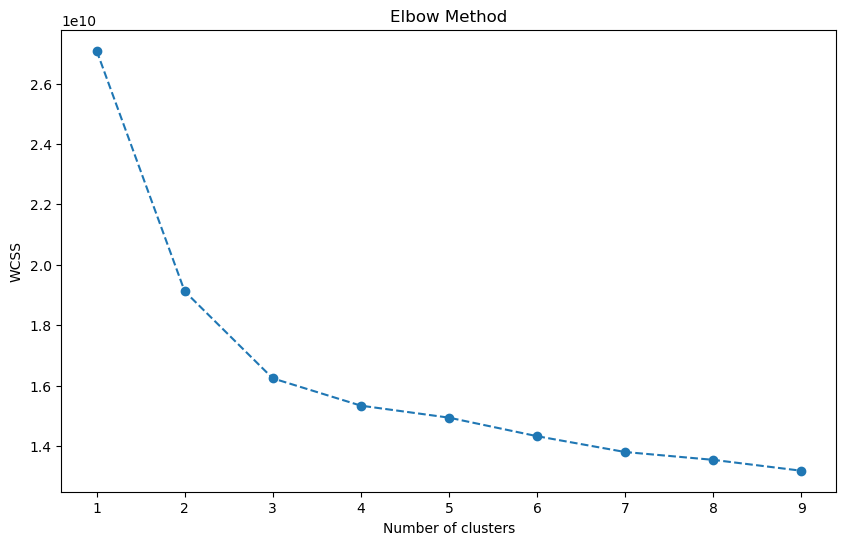

In [ ]:
# Elbow Method
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

It appears that 3 clusters is optimal.

In [ ]:
# K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3)
kmeans_labels = kmeans.fit_predict(cluster_df)
final_df['cluster'] = kmeans_labels

/var/folders/yw/39mp1rt91gn10x2v8bmnwm0w0000gn/T/ipykernel_66677/1025417316.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df['cluster'] = kmeans_labels


In [ ]:
respondent_dfs = {}
BASE_RESULT = os.path.abspath(os.path.join(os.getcwd(), "../../"))

years = [y for y in range(2010, 2025) if y != 2020]

for year in years:
    respondent_dfs[year] = pd.read_csv(os.path.join(BASE_RESULT, f'ATUS Data/atusresp_{year}.dat'))
    respondent_dfs[year].columns = respondent_dfs[year].columns.str.upper()
    respondent_dfs[year]['YEAR'] = year

respondent_df = pd.concat(respondent_dfs.values(), ignore_index=True)
merged_df = pd.merge(respondent_df, final_df, on=["TUCASEID", "YEAR"], how="inner")
merged_df.to_csv('kmeans_clustering_output.csv', index=False)